In [10]:
import torch
from torch.autograd import grad
from torch.optim.lr_scheduler import ReduceLROnPlateau
import sys
import datetime
sys.path.append('../..')
from src import train, utils
from src import calculus as calc
import src.data.cube_domain as cb
import src.models.mlp_model as mm

In [11]:
from typing import Tuple

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRAIN_TEMP_SAVE_PATH = './most_eff_model.pt'
NU = 1 / 100
RE = 1 / NU
T_MAX = 1
L_BOUNDS = [0, 0]
U_BOUNDS = [1, 1]

In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
# NOTE: input is assumed to have requires_grad=True
def pde_res(output: torch.Tensor, input: torch.Tensor) -> Tuple[torch.Tensor]:
    u, v, p = output[:, 0:1], output[:, 1:2], output[:, 2:3]
    
    u_grad = grad(u, input, torch.ones_like(u), create_graph=True)[0]
    v_grad = grad(v, input, torch.ones_like(v), create_graph=True)[0]
    u_x, u_y = u_grad[:, 0:1], u_grad[:, 1:2]
    v_x, v_y = v_grad[:, 0:1], v_grad[:, 1:2]
    
    u_xx = grad(u_x, input, torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
    u_yy = grad(u_y, input, torch.ones_like(u_y), create_graph=True)[0][:, 1:2]
    v_xx = grad(v_x, input, torch.ones_like(v_x), create_graph=True)[0][:, 0:1]
    v_yy = grad(v_y, input, torch.ones_like(v_y), create_graph=True)[0][:, 1:2]
    
    p_grad = grad(p, input, torch.ones_like(p), create_graph=True)[0]
    p_x, p_y = p_grad[:, 0:1], p_grad[:, 1:2]
    
    res_a = u * u_x + v * u_y + p_x - NU * (u_xx + u_yy)
    res_b = u * v_x + v * v_y + p_y - NU * (v_xx + v_yy)
    res_ct = u_x + v_y
    
    return res_a, res_b, res_ct
    
def pde_loss(model: torch.nn.Module, domain: cb.CubeDomain):
    pde_pts = domain.interior.requires_grad_(True)
    pde_out = model(pde_pts).requires_grad_(True)
    pde_res_a, pde_res_b, pde_res_ct  = pde_res(pde_out, pde_pts)
    return [torch.mean(pde_res_a**2 + pde_res_b**2), torch.mean(pde_res_ct**2)]

In [15]:
domain_ctx = cb.CubeContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    dim=2,
    device=device,
    int_sampling='Latin',
    N_int=1000,
    N_sides=[(100, 100), (100, 1000)],
)

domain = cb.CubeDomain(domain_ctx)
 
def bnd_loss(model: torch.nn.Module, domain: cb.CubeDomain):
    top_pts = domain.sides[1][1].requires_grad_(True)
    top_out = model(top_pts)
    
    u_x_top = torch.full((top_pts.shape[0], 1), 1, device=device)
    top_rest = torch.zeros((top_pts.shape[0], 2), device=device)
    top_cond = torch.cat([u_x_top, top_rest], dim=1)
    
    top_loss = torch.mean((top_out - top_cond)**2)
    
    int_pts = domain.interior.requires_grad_(True)
    int_out = model(int_pts)
    int_lapl = calc.laplacian(int_pts, int_out, device, False)
    int_loss = torch.mean(int_lapl**2)
    
    return [top_loss, int_loss]
    
boundary_model_ctx = mm.ModelContext(
    input_dim=2,
    output_dim=3,
    layer=[64, 64],
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS
)

bnd_model = mm.MLPModel(boundary_model_ctx).to(device)
bnd_optim = torch.optim.Adam(bnd_model.parameters(), lr=0.0001)

boundary_train_ctx = train.TrainingContext(
    model=bnd_model,
    optimizer=bnd_optim,
    domain=domain,
    loss_fn=bnd_loss,
    resample=False,
    epochs=5_000,
    monitor_gradient=True
)


_, _ = train.simple_train(boundary_train_ctx)

Loss at epoch 1 is: 0.349590927362442. Total gradient norm: 2.049036285570027 
Loss at epoch 100 is: 0.04780474677681923. Total gradient norm: 0.4083437314682853 
Loss at epoch 200 is: 0.006968600209802389. Total gradient norm: 0.0677476357693511 
Loss at epoch 300 is: 0.0036195043940097094. Total gradient norm: 0.03152029344228877 
Loss at epoch 400 is: 0.0020224140025675297. Total gradient norm: 0.021335530073715473 
Loss at epoch 500 is: 0.0011309233959764242. Total gradient norm: 0.014761752650145744 
Loss at epoch 600 is: 0.0006428836495615542. Total gradient norm: 0.010135796760141556 
Loss at epoch 700 is: 0.0003800909616984427. Total gradient norm: 0.006955335205962348 
Loss at epoch 800 is: 0.0002364969113841653. Total gradient norm: 0.004840027457747675 
Loss at epoch 900 is: 0.00015560767496936023. Total gradient norm: 0.0034353033014325423 
Loss at epoch 1000 is: 0.00010872334678424522. Total gradient norm: 0.0024827015635591164 
Loss at epoch 1100 is: 8.084279397735372e-05

In [18]:
# defining the smooth bump function

def f(x: float) -> float:
    return torch.where(x > 0, torch.exp(-1/x), 0)
    
def g(x: float) -> float:
    return f(x) / (f(x) + f(1 - x))

delta = 0.4


from numpy import pi

K = 2
A = 5e-2

def smoothing_fn(x: torch.Tensor):
    return torch.cos(0.5 * pi * x[:, 0:1]) * torch.cos(0.5 * pi * x[:, 1:2])
    # return torch.cos(pi * x[:, 0:1]) * torch.cos(pi * x[:, 1:2])    
    # return g((x[:, 0:1] - L_BOUNDS[0])/(delta)) * g((U_BOUNDS[0] - x[:, 0:1])/(delta)) *\
    #        g((x[:, 1:2] - L_BOUNDS[1])/(delta)) * g((U_BOUNDS[1] - x[:, 1:2])/(delta))
    
def model_decorator(model_in : torch.Tensor, model_out: torch.Tensor):
    return bnd_model(model_in) + torch.mul(smoothing_fn(model_in), model_out)

In [ ]:
model_ctx = mm.ModelContext(
    input_dim=2,
    output_dim=3,
    layer=[32, 32, 32, 32],
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    hard_enforce_boundary=True,
    decorator=model_decorator
)

model = mm.MLPModel(model_ctx).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_VALUE)

def init_weights(m):
    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight, gain=torch.nn.init.calculate_gain('tanh'))
        torch.nn.init.zeros_(m.bias)

model.apply(init_weights)

AttributeError: module 'torch.optim' has no attribute 'Muon'

In [ ]:
domain_ctx = cb.CubeContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    dim=2,
    device=device,
    int_sampling='Latin',
    N_int=10_000,
    N_sides=[(0, 0), (0, 0)],
)

domain = cb.CubeDomain(domain_ctx)

In [ ]:
train_ctx = train.TrainingContext(
    model=model,
    optimizer=optimizer,
    domain=domain,
    loss_fn=pde_loss,
    resample=False,
    epochs=120_000,
    monitor_gradient=True,
    monitor_lr=True
)

_, _ = train.simple_train(train_ctx)


Loss at epoch 1 is: 63.90156173706055. Total gradient norm: 704.1987960040574 Current learing rate: 0.001 
Loss at epoch 100 is: 0.1625785082578659. Total gradient norm: 1.7751453768787437 Current learing rate: 0.001 
Loss at epoch 200 is: 0.09468679130077362. Total gradient norm: 0.40179929795658953 Current learing rate: 0.001 
Loss at epoch 300 is: 0.08009402453899384. Total gradient norm: 0.21885224821859545 Current learing rate: 0.001 
Loss at epoch 400 is: 0.07376420497894287. Total gradient norm: 0.14436586517112032 Current learing rate: 0.001 
Loss at epoch 500 is: 0.07007427513599396. Total gradient norm: 0.10847294158038968 Current learing rate: 0.001 
Loss at epoch 600 is: 0.0675496906042099. Total gradient norm: 0.08740412770289577 Current learing rate: 0.001 
Loss at epoch 700 is: 0.06568317860364914. Total gradient norm: 0.07332798232301843 Current learing rate: 0.001 
Loss at epoch 800 is: 0.0642358809709549. Total gradient norm: 0.06307794453120245 Current learing rate: 

KeyboardInterrupt: 

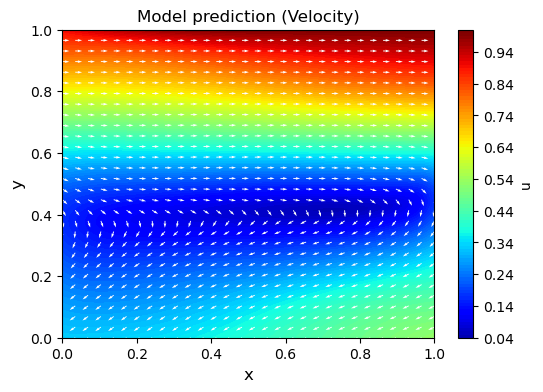

In [ ]:
# define plot context
plot_ctx = utils.PlotContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    function_names = ['u'],
    titles= ['Model prediction (Velocity)'],
    device=device,
    vmin=0,
    vmax=1,
    patches=[],
    N = 100
)

# 
def velocity(x: torch.Tensor) -> torch.Tensor:
    x.requires_grad_(True)
    out = model(x)
    u = out[:, 0:1]
    v = out[:, 1:2]
    
    return torch.cat([u, v], dim=1)

utils.plot_vector_field_2d([model], plot_ctx, N=100, n_width=30, n_heigth=30)

plot_ctx.vmin=-0.53
plot_ctx.vmax=-0.43
plot_ctx.titles = ['Model prediction (Streamfunction)']
plot_ctx.function_names = [r'$\psi$']

#utils.plot_function_on_2d_cube([lambda x: model(x)[:, 0]], plot_ctx)

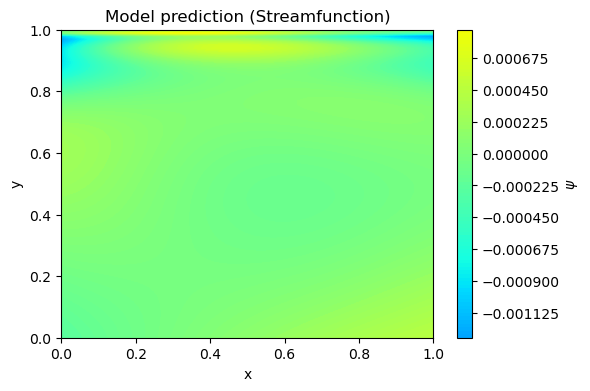

In [ ]:
plot_ctx.vmax=0.003
plot_ctx.vmin=-0.003
utils.plot_function_on_2d_cube([lambda x: bnd_model(x)[:, 1]], plot_ctx)